# Proyek Analisis Data: E-Commerce Public Dataset (Olist Brazil)
**Nama:** Salsabila Yufli Ramadhani
**Email:** salsabilayufliramadhani@gmail.com
**ID Dicoding:** salsabilayufliramadhani

## 1. Menentukan Pertanyaan Bisnis

Berikut adalah pertanyaan bisnis yang akan dijawab melalui proses analisis data:

1. **Bagaimana tren jumlah order dan total revenue bulanan selama periode Januari 2017 hingga Agustus 2018, dan pada bulan apa penjualan mencapai puncaknya?**
2. **Kategori produk apa yang menghasilkan revenue terbesar dan memiliki jumlah order terbanyak sepanjang tahun 2017–2018?**
3. **Berapa persentase pesanan yang terlambat dari estimasi pengiriman selama periode 2017–2018, dan seberapa besar perbedaan rata-rata skor ulasan antara pesanan yang terlambat dengan yang tepat waktu?**
4. **Berdasarkan analisis RFM (Recency, Frequency, Monetary) terhadap data transaksi 2017–2018, berapa proporsi pelanggan di setiap segmen (Champions, Loyal Customers, Potential Loyalists, At Risk, Lost) dan berapa rata-rata nilai transaksi (monetary) dari segmen Champions dibandingkan segmen lainnya?**
5. **Negara bagian mana di Brazil yang menghasilkan total revenue dan jumlah pelanggan unik tertinggi selama periode 2017–2018, serta seberapa besar kontribusinya terhadap total revenue keseluruhan?**

## 2. Data Wrangling

### 2.1 Gathering Data

Pada tahap ini, kita mengumpulkan dan memuat semua dataset yang dibutuhkan ke dalam format DataFrame pandas.

Dataset yang digunakan adalah **Olist Brazil E-Commerce Public Dataset**, yang terdiri dari beberapa file CSV yang saling berelasi:

| Dataset | Deskripsi |
|---|---|
| `orders_dataset.csv` | Informasi pesanan (status, waktu pembelian, estimasi pengiriman) |
| `order_items_dataset.csv` | Detail item dalam setiap pesanan (harga, seller) |
| `order_payments_dataset.csv` | Informasi pembayaran (metode, nilai total) |
| `order_reviews_dataset.csv` | Ulasan pelanggan (skor 1–5, teks komentar) |
| `products_dataset.csv` | Informasi produk (kategori, dimensi, berat) |
| `customers_dataset.csv` | Data pelanggan (kota, state, zip code) |
| `sellers_dataset.csv` | Data seller (kota, state) |
| `geolocation_dataset.csv` | Data koordinat geografis berdasarkan zip code |
| `product_category_name_translation.csv` | Terjemahan nama kategori produk dari Portugis ke Inggris |

Seluruh dataset di-load menggunakan `pd.read_csv()` dan disimpan dalam variabel DataFrame masing-masing untuk diproses lebih lanjut.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


In [2]:
# Load all datasets
customers_df    = pd.read_csv('data/customers_dataset.csv')
geolocation_df  = pd.read_csv('data/geolocation_dataset.csv')
order_items_df  = pd.read_csv('data/order_items_dataset.csv')
order_payments_df = pd.read_csv('data/order_payments_dataset.csv')
order_reviews_df  = pd.read_csv('data/order_reviews_dataset.csv')
orders_df       = pd.read_csv('data/orders_dataset.csv')
products_df     = pd.read_csv('data/products_dataset.csv')
sellers_df      = pd.read_csv('data/sellers_dataset.csv')
category_df     = pd.read_csv('data/product_category_name_translation.csv')

print('Shape masing-masing dataset:')
for name, df in [('customers', customers_df), ('geolocation', geolocation_df),
                  ('order_items', order_items_df), ('order_payments', order_payments_df),
                  ('order_reviews', order_reviews_df), ('orders', orders_df),
                  ('products', products_df), ('sellers', sellers_df), ('category', category_df)]:
    print(f'  {name:20s}: {df.shape}')

Shape masing-masing dataset:
  customers           : (99441, 5)
  geolocation         : (1000163, 5)
  order_items         : (112650, 7)
  order_payments      : (103886, 5)
  order_reviews       : (99224, 7)
  orders              : (99441, 8)
  products            : (32951, 9)
  sellers             : (3095, 4)
  category            : (71, 2)


In [3]:
# Preview main tables
print('=== Orders Dataset ===')
display(orders_df.head(3))
print('\n=== Order Items Dataset ===')
display(order_items_df.head(3))
print('\n=== Customers Dataset ===')
display(customers_df.head(3))

=== Orders Dataset ===


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



=== Order Items Dataset ===


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87



=== Customers Dataset ===


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


### 2.2 Assessing Data

Pada tahap ini, kita menilai kualitas data dengan memeriksa empat aspek utama:

1. **Missing Values** — Nilai kosong yang dapat mengganggu analisis
2. **Duplicate Data** — Baris data yang duplikat dan perlu dihapus
3. **Incorrect Data Types** — Kolom bertipe data yang tidak sesuai (misalnya tanggal bertipe string)
4. **Outliers** — Nilai ekstrem yang jauh dari distribusi normal

Proses assessing data penting dilakukan **sebelum** analisis agar hasil yang diperoleh akurat dan dapat dipercaya. Berikut adalah pemeriksaan yang dilakukan pada masing-masing dataset:

In [4]:
print('='*60)
print('MISSING VALUE PER DATASET')
print('='*60)
for name, df in [('orders_df', orders_df), ('order_items_df', order_items_df),
                  ('customers_df', customers_df), ('products_df', products_df),
                  ('order_reviews_df', order_reviews_df)]:
    mv = df.isnull().sum()
    mv = mv[mv > 0]
    if len(mv) > 0:
        print(f'\n{name}:')
        print(mv.to_string())
    else:
        print(f'\n{name}: Tidak ada missing value ✅')

MISSING VALUE PER DATASET

orders_df:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965

order_items_df: Tidak ada missing value ✅

customers_df: Tidak ada missing value ✅

products_df:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2

order_reviews_df:
review_comment_title      87656
review_comment_message    58247


In [5]:
print('=== Tipe Data orders_df ===')
print(orders_df.dtypes)
print('\n⚠️  Kolom tanggal masih bertipe object, perlu dikonversi ke datetime')

=== Tipe Data orders_df ===
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

⚠️  Kolom tanggal masih bertipe object, perlu dikonversi ke datetime


In [6]:
print('DUPLICATE DATA:')
for name, df in [('orders_df', orders_df), ('order_items_df', order_items_df),
                  ('customers_df', customers_df), ('products_df', products_df)]:
    dup = df.duplicated().sum()
    status = '✅' if dup == 0 else '⚠️'
    print(f'  {status} {name}: {dup} duplikat')

DUPLICATE DATA:


  ✅ orders_df: 0 duplikat


  ✅ order_items_df: 0 duplikat


  ✅ customers_df: 0 duplikat
  ✅ products_df: 0 duplikat


In [7]:
print('=== Statistik Deskriptif order_items_df ===')
display(order_items_df[['price', 'freight_value']].describe())

# IQR method untuk identifikasi outlier
Q1 = order_items_df['price'].quantile(0.25)
Q3 = order_items_df['price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = order_items_df[(order_items_df['price'] < lower) | (order_items_df['price'] > upper)]
print(f'\n⚠️  Jumlah outlier pada kolom price: {len(outliers)} baris ({len(outliers)/len(order_items_df)*100:.1f}%)')
print(f'   Lower bound: R${lower:.2f}, Upper bound: R${upper:.2f}')

=== Statistik Deskriptif order_items_df ===


,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000



⚠️  Jumlah outlier pada kolom price: 8427 baris (7.5%)
   Lower bound: R$-102.60, Upper bound: R$277.40


**Rangkuman Hasil Assessing Data:**

Setelah memeriksa seluruh dataset, berikut adalah masalah kualitas data yang ditemukan:

| No | Dataset | Masalah | Detail |
|---|---|---|---|
| 1 | `orders_df` | Missing value | Kolom `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date` memiliki nilai kosong karena pesanan belum selesai/dibatalkan |
| 2 | `products_df` | Missing value | Kolom `product_category_name` memiliki beberapa nilai kosong |
| 3 | `orders_df` | Incorrect data type | Seluruh kolom tanggal bertipe `object` (string), seharusnya `datetime64` |
| 4 | `order_items_df` | Outlier | Terdapat outlier pada kolom `price` dengan nilai sangat tinggi |

**Rencana Penanganan:**
- Missing value pada kolom tanggal kritis (`order_delivered_customer_date`) → drop baris tersebut karena dibutuhkan untuk analisis pengiriman
- Missing value pada nama kategori produk → isi dengan `'unknown'` agar tidak kehilangan data order
- Incorrect data type kolom tanggal → konversi ke tipe `datetime` menggunakan `pd.to_datetime()`
- Outlier pada `price` → **dibiarkan**, karena bukan merupakan data error, melainkan variasi harga wajar di e-commerce (produk mahal memang ada)

### 2.3 Cleaning Data

Berdasarkan masalah yang ditemukan pada tahap Assessing Data, berikut langkah-langkah pembersihan data yang dilakukan:

**1. Konversi Tipe Data Tanggal**
Kolom-kolom tanggal di `orders_df` dikonversi dari `object` ke `datetime64` menggunakan `pd.to_datetime()`. Ini penting agar kita bisa melakukan operasi tanggal seperti menghitung selisih hari dan mengekstrak bulan/tahun.

**2. Menangani Missing Value pada Kolom Tanggal**
Baris dengan `order_delivered_customer_date` yang kosong di-drop karena kolom ini digunakan untuk menghitung apakah pengiriman terlambat atau tidak. Pesanan yang belum terkirim tidak relevan untuk analisis performa pengiriman.

**3. Menangani Missing Value pada Kategori Produk**
Nilai kosong pada `product_category_name` diisi dengan string `'unknown'` agar data pesanan yang berelasi tidak hilang saat proses merge/join antar tabel.

**4. Membuat Kolom Turunan (`is_late`)**
Setelah data bersih, dibuat kolom baru `is_late` yang bernilai `1` jika `order_delivered_customer_date > order_estimated_delivery_date`, dan `0` jika tepat waktu. Kolom ini akan digunakan untuk analisis performa pengiriman (Q3).

**5. Merge Seluruh Dataset menjadi `main_df`**
Seluruh dataset yang sudah bersih di-merge menjadi satu DataFrame utama (`main_df`) yang berisi semua informasi yang dibutuhkan: order, item, pembayaran, ulasan, produk, dan pelanggan.

In [8]:
# --- 1. Konversi tipe data tanggal ---
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

print('✅ Kolom tanggal berhasil dikonversi ke datetime')
print(orders_df[date_cols].dtypes)

# --- 2. Handle missing value di orders_df ---
# Hanya drop baris yang delivered_customer_date kosong tapi statusnya delivered
orders_clean = orders_df[~(
    (orders_df['order_status'] == 'delivered') &
    (orders_df['order_delivered_customer_date'].isnull())
)].copy()
print(f'\n✅ orders_df: {len(orders_df)} → {len(orders_clean)} baris setelah cleaning')

# --- 3. Handle missing value di products_df ---
products_df['product_category_name'] = products_df['product_category_name'].fillna('unknown')
print(f'\n✅ Missing value kategori produk diisi dengan "unknown"')

# --- 4. Merge category translation ---
products_df = products_df.merge(category_df, on='product_category_name', how='left')
products_df['product_category_name_english'] = products_df['product_category_name_english'].fillna('unknown')
print(f'\n✅ Terjemahan kategori berhasil di-merge')

✅ Kolom tanggal berhasil dikonversi ke datetime
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

✅ orders_df: 99441 → 99433 baris setelah cleaning

✅ Missing value kategori produk diisi dengan "unknown"

✅ Terjemahan kategori berhasil di-merge


In [9]:
# --- Merge semua tabel menjadi satu DataFrame utama ---
main_df = orders_clean.merge(order_items_df, on='order_id', how='left')
main_df = main_df.merge(products_df[['product_id','product_category_name_english']], on='product_id', how='left')
main_df = main_df.merge(customers_df, on='customer_id', how='left')
main_df = main_df.merge(order_payments_df.groupby('order_id')['payment_value'].sum().reset_index(), on='order_id', how='left')
main_df = main_df.merge(order_reviews_df.groupby('order_id')['review_score'].mean().reset_index(), on='order_id', how='left')

# Tambah fitur turunan
main_df['order_month'] = main_df['order_purchase_timestamp'].dt.to_period('M')
main_df['is_late'] = (main_df['order_delivered_customer_date'] > main_df['order_estimated_delivery_date']).astype(int)

print(f'✅ Main DataFrame berhasil dibuat: {main_df.shape}')
display(main_df.head(3))

# Simpan ke dashboard/main_data.csv
main_df.to_csv('dashboard/main_data.csv', index=False)
print('\n✅ main_data.csv berhasil disimpan ke folder dashboard/')

✅ Main DataFrame berhasil dibuat: (113417, 23)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,freight_value,product_category_name_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,review_score,order_month,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,8.72,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,4.0,2017-10,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,...,22.76,perfumery,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,4.0,2018-07,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,...,19.22,auto,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,5.0,2018-08,0



✅ main_data.csv berhasil disimpan ke folder dashboard/


## 3. Exploratory Data Analysis (EDA)

Pada tahap Exploratory Data Analysis (EDA), kita mengeksplorasi data untuk menemukan pola, tren, dan hubungan antar variabel **sebelum** membuat visualisasi final.

Tujuan EDA adalah:
- Memahami distribusi dan karakteristik setiap variabel
- Menemukan pola tersembunyi dalam data
- Memvalidasi asumsi yang akan digunakan dalam analisis
- Mempersiapkan data agregasi yang akan divisualisasikan

EDA dilakukan untuk menjawab 5 pertanyaan bisnis yang telah ditetapkan di awal. Setiap pertanyaan dijawab melalui proses groupby, agregasi, dan eksplorasi data yang relevan.

### EDA Q1: Tren Jumlah Order & Revenue Bulanan (Jan 2017 – Agust 2018)

**Tujuan:** Memahami bagaimana jumlah order dan revenue berubah dari bulan ke bulan selama periode analisis.

**Proses:**
- Data di-filter untuk periode Januari 2017 hingga Agustus 2018
- Dikelompokkan per bulan menggunakan `dt.to_period('M')` untuk mendapatkan periode bulanan
- Dihitung `nunique()` untuk order (menghindari duplikasi dari join) dan `sum()` untuk revenue
- Dicari bulan dengan nilai puncak menggunakan `idxmax()`

**Variabel yang digunakan:**
- `order_purchase_timestamp` → diekstrak sebagai periode bulanan
- `order_id` → dihitung unik per bulan sebagai jumlah order
- `payment_value` → dijumlahkan per bulan sebagai total revenue

In [10]:
# Filter rentang waktu
df_filtered = main_df[
    (main_df['order_purchase_timestamp'] >= '2017-01-01') &
    (main_df['order_purchase_timestamp'] <= '2018-08-31')
].copy()

monthly = df_filtered.groupby('order_month').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('payment_value', 'sum')
).reset_index()
monthly['order_month_str'] = monthly['order_month'].astype(str)

print('Tren Bulanan:')
print(monthly.to_string(index=False))
print(f'\nBulan dengan order tertinggi: {monthly.loc[monthly.total_orders.idxmax(), "order_month_str"]}')
print(f'Bulan dengan revenue tertinggi: {monthly.loc[monthly.total_revenue.idxmax(), "order_month_str"]}')

Tren Bulanan:
order_month  total_orders  total_revenue order_month_str
    2017-01           800      189015.66         2017-01
    2017-02          1780      349701.93         2017-02
    2017-03          2682      544738.23         2017-03
    2017-04          2404      510891.55         2017-04
    2017-05          3699      730823.09         2017-05
    2017-06          3245      608891.38         2017-06
    2017-07          4026      744599.53         2017-07
    2017-08          4331      876129.37         2017-08
    2017-09          4285     1023095.49         2017-09
    2017-10          4631     1031505.53         2017-10
    2017-11          7543     1599309.35         2017-11
    2017-12          5673     1057582.34         2017-12
    2018-01          7269     1415348.54         2018-01
    2018-02          6728     1311260.71         2018-02
    2018-03          7211     1480045.50         2018-03
    2018-04          6939     1497843.94         2018-04
    2018-05      

### EDA Q2: Kategori Produk Terlaris (2017–2018)

**Tujuan:** Mengidentifikasi kategori produk mana yang paling banyak menghasilkan revenue dan order.

**Proses:**
- Data dikelompokkan berdasarkan `product_category_name_english`
- Dihitung total order (nunique order_id), total revenue (sum payment_value), dan rata-rata harga
- Diurutkan descending untuk mendapatkan top kategori

**Catatan Teknis:**
Kita menggunakan `product_category_name_english` (nama dalam bahasa Inggris) yang didapatkan dari hasil merge dengan tabel `product_category_name_translation`. Ini dilakukan agar analisis lebih mudah dipahami secara internasional.

**Variabel yang digunakan:**
- `product_category_name_english` → variabel groupby
- `order_id` → dihitung nunique sebagai jumlah order per kategori
- `payment_value` → dijumlahkan sebagai total revenue per kategori
- `price` → dirata-rata sebagai indikator harga jual per kategori

In [11]:
category_analysis = main_df.groupby('product_category_name_english').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('payment_value', 'sum')
).reset_index().sort_values('total_revenue', ascending=False)

print('Top 10 Kategori berdasarkan Revenue:')
display(category_analysis.head(10))

Top 10 Kategori berdasarkan Revenue:


,product_category_name_english,total_orders,total_revenue
7,bed_bath_table,9417,1712553.67
43,health_beauty,8836,1657373.12
15,computers_accessories,6688,1585210.33
39,furniture_decor,6449,1430176.39
71,watches_gifts,5622,1428900.54
65,sports_leisure,7719,1391933.56
49,housewares,5884,1094758.13
5,auto,3896,852159.50
42,garden_tools,3518,838280.75
20,cool_stuff,3632,779698.00


### EDA Q3: Performa Pengiriman & Dampak terhadap Review Score

**Tujuan:** Mengukur tingkat keterlambatan pengiriman dan dampaknya terhadap kepuasan pelanggan (review score).

**Proses:**
- Kolom `is_late` digunakan (sudah dibuat pada tahap Cleaning):
  - `is_late = 1` → pesanan terlambat dari estimasi
  - `is_late = 0` → pesanan tepat waktu
- Dihitung persentase keterlambatan: `is_late.mean() * 100`
- Dihitung rata-rata review score berdasarkan status keterlambatan dengan `groupby('is_late')`
- Dihitung durasi pengiriman aktual: `order_delivered_customer_date - order_purchase_timestamp`

**Hipotesis:** Pesanan yang terlambat akan mendapatkan review score lebih rendah karena pelanggan kecewa dengan layanan pengiriman.

**Variabel yang digunakan:**
- `is_late` → indikator keterlambatan (0/1)
- `review_score` → skor ulasan pelanggan (skala 1–5)
- `order_delivered_customer_date` & `order_purchase_timestamp` → untuk menghitung durasi pengiriman aktual dalam hari

In [12]:
delivery_analysis = main_df.dropna(subset=['order_delivered_customer_date', 'review_score'])
late_pct = delivery_analysis['is_late'].mean() * 100
print(f'Persentase pesanan terlambat: {late_pct:.1f}%')

review_by_delivery = delivery_analysis.groupby('is_late')['review_score'].mean()
print('\nRata-rata review score:')
print(f'  Tepat waktu (0): {review_by_delivery.get(0, 0):.2f}')
print(f'  Terlambat  (1): {review_by_delivery.get(1, 0):.2f}')

Persentase pesanan terlambat: 7.8%

Rata-rata review score:
  Tepat waktu (0): 4.21
  Terlambat  (1): 2.55


### EDA Q4: Segmentasi Pelanggan dengan Analisis RFM

**Tujuan:** Mengelompokkan pelanggan ke dalam segmen berdasarkan perilaku transaksi mereka menggunakan metode RFM.

**Penjelasan Metode RFM:**
- **Recency (R):** Seberapa baru pelanggan terakhir kali bertransaksi (dalam hari). Semakin kecil nilainya, semakin baik (pelanggan masih aktif).
- **Frequency (F):** Seberapa sering pelanggan bertransaksi. Semakin tinggi, semakin loyal.
- **Monetary (M):** Seberapa besar total nilai transaksi pelanggan. Semakin tinggi, semakin valuable.

**Proses Scoring:**
1. Setiap dimensi R, F, M diberi skor 1–5 menggunakan `pd.qcut()` (pembagian kuantil)
2. Untuk Recency: skor 5 = paling baru (terbaik), skor 1 = paling lama (terburuk)
3. Untuk Frequency & Monetary: skor 5 = paling tinggi (terbaik), skor 1 = paling rendah
4. RFM Score total = R_score + F_score + M_score (rentang 3–15)

**Segmentasi berdasarkan Total RFM Score:**
| Segmen | RFM Score | Karakteristik |
|---|---|---|
| Champions | ≥ 13 | Baru bertransaksi, sering beli, nilai tinggi |
| Loyal Customers | 10–12 | Sering beli, mulai kurang aktif |
| Potential Loyalists | 7–9 | Potensi baik, perlu didorong |
| At Risk | 5–6 | Pernah aktif, mulai jarang bertransaksi |
| Lost | < 5 | Sudah lama tidak bertransaksi |

**Variabel yang digunakan:**
- `customer_unique_id` → identitas unik pelanggan
- `order_purchase_timestamp` → untuk menghitung Recency
- `order_id` → dihitung nunique untuk Frequency
- `payment_value` → dijumlahkan untuk Monetary

In [13]:
# Tentukan reference date = tanggal maksimum + 1 hari
reference_date = main_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm_df = main_df.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('payment_value', 'sum')
).reset_index()

# Scoring 1-5 (5 = terbaik)
rfm_df['r_score'] = pd.qcut(rfm_df['recency'], 5, labels=[5,4,3,2,1], duplicates='drop').astype(int)
rfm_df['f_score'] = pd.qcut(rfm_df['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm_df['m_score'] = pd.qcut(rfm_df['monetary'], 5, labels=[1,2,3,4,5], duplicates='drop').astype(int)
rfm_df['rfm_score'] = rfm_df['r_score'] + rfm_df['f_score'] + rfm_df['m_score']

# Segmentasi
def segment(row):
    score = row['rfm_score']
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal Customers'
    elif score >= 7:
        return 'Potential Loyalists'
    elif score >= 5:
        return 'At Risk'
    else:
        return 'Lost'

rfm_df['segment'] = rfm_df.apply(segment, axis=1)

seg_summary = rfm_df.groupby('segment').agg(
    jumlah_pelanggan=('customer_unique_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean')
).reset_index().sort_values('jumlah_pelanggan', ascending=False)

print('=== RFM Segmentation Summary ===')
display(seg_summary)

=== RFM Segmentation Summary ===


,segment,jumlah_pelanggan,avg_recency,avg_frequency,avg_monetary
4,Potential Loyalists,39504,315.995595,1.004481,159.163724
3,Loyal Customers,32438,226.344226,1.044269,281.231887
0,At Risk,12688,407.766630,1.000000,72.449218
1,Champions,8234,142.692373,1.210347,483.926524
2,Lost,3224,487.253722,1.000000,48.156749


### EDA Q5: Distribusi Geografis Pelanggan & Revenue per Negara Bagian

**Tujuan:** Mengidentifikasi negara bagian (state) di Brazil yang mendominasi dari sisi jumlah pelanggan dan total revenue.

**Proses:**
- Data dikelompokkan berdasarkan `customer_state`
- Dihitung jumlah pelanggan unik (`nunique()`) dan total revenue (`sum()`)
- Dihitung persentase kontribusi setiap state terhadap total revenue nasional
- Data geolokasi (latitude/longitude) di-merge untuk keperluan visualisasi heatmap

**Konteks Geografis Brazil:**
Brazil terdiri dari 26 negara bagian + 1 distrik federal (DF). Populasi terkonsentrasi di wilayah tenggara, terutama di state São Paulo (SP), Rio de Janeiro (RJ), dan Minas Gerais (MG) yang merupakan pusat ekonomi utama negara.

**Variabel yang digunakan:**
- `customer_state` → kode state pelanggan (2 huruf, misal: SP, RJ, MG)
- `customer_unique_id` → dihitung nunique sebagai jumlah pelanggan per state
- `payment_value` → dijumlahkan sebagai total revenue per state
- `geolocation_lat` & `geolocation_lng` → koordinat untuk heatmap

In [14]:
state_analysis = main_df.groupby('customer_state').agg(
    total_customers=('customer_unique_id', 'nunique'),
    total_revenue=('payment_value', 'sum')
).reset_index().sort_values('total_revenue', ascending=False)

print('Top 10 State berdasarkan Revenue:')
display(state_analysis.head(10))

Top 10 State berdasarkan Revenue:


,customer_state,total_customers,total_revenue
25,SP,40295,7672003.63
18,RJ,12384,2783724.26
10,MG,11259,2341861.47
22,RS,5276,1151825.17
17,PR,4882,1074614.19
4,BA,3277,802416.72
23,SC,3534,799135.92
8,GO,1952,516182.51
6,DF,2075,434512.55
7,ES,1964,406946.26


## 4. Visualization & Explanatory Analysis

Pada tahap ini, hasil EDA divisualisasikan menggunakan **Matplotlib**, **Seaborn**, dan **Folium** untuk menjawab setiap pertanyaan bisnis secara visual dan eksplanatif.

**Prinsip visualisasi yang diterapkan:**
- Setiap chart dilengkapi dengan **judul**, **label sumbu**, dan **keterangan nilai** agar mudah dibaca
- Warna digunakan secara konsisten: **biru (#4C6EF5)** untuk data umum, **kuning (#FFD43B)** untuk highlight nilai tertinggi
- Chart yang membandingkan dua kategori bermakna (tepat waktu vs terlambat) menggunakan warna berbeda (hijau vs merah) untuk memperjelas kontras
- Setiap visualisasi diikuti dengan **insight** yang menjabarkan temuan utama dari chart tersebut

Urutan visualisasi mengikuti urutan pertanyaan bisnis (Q1–Q5).

### Visualisasi 1: Tren Order & Revenue Bulanan (Jan 2017 – Agust 2018)

**Pertanyaan (SMART):** Bagaimana tren jumlah order dan total revenue bulanan selama periode **Januari 2017 hingga Agustus 2018**, dan pada bulan apa penjualan mencapai puncaknya?

**Jenis Chart:** Dual-axis chart — bar chart untuk jumlah order (sumbu kiri) dan line chart untuk revenue (sumbu kanan).

**Alasan pemilihan chart:** Dual-axis dipilih karena kita ingin menampilkan dua metrik dengan satuan berbeda (jumlah order vs rupiah) dalam satu visualisasi agar tren keduanya dapat dibandingkan secara langsung. Bar digunakan untuk order (data diskret per bulan), sedangkan line untuk revenue (menunjukkan tren kontinu).

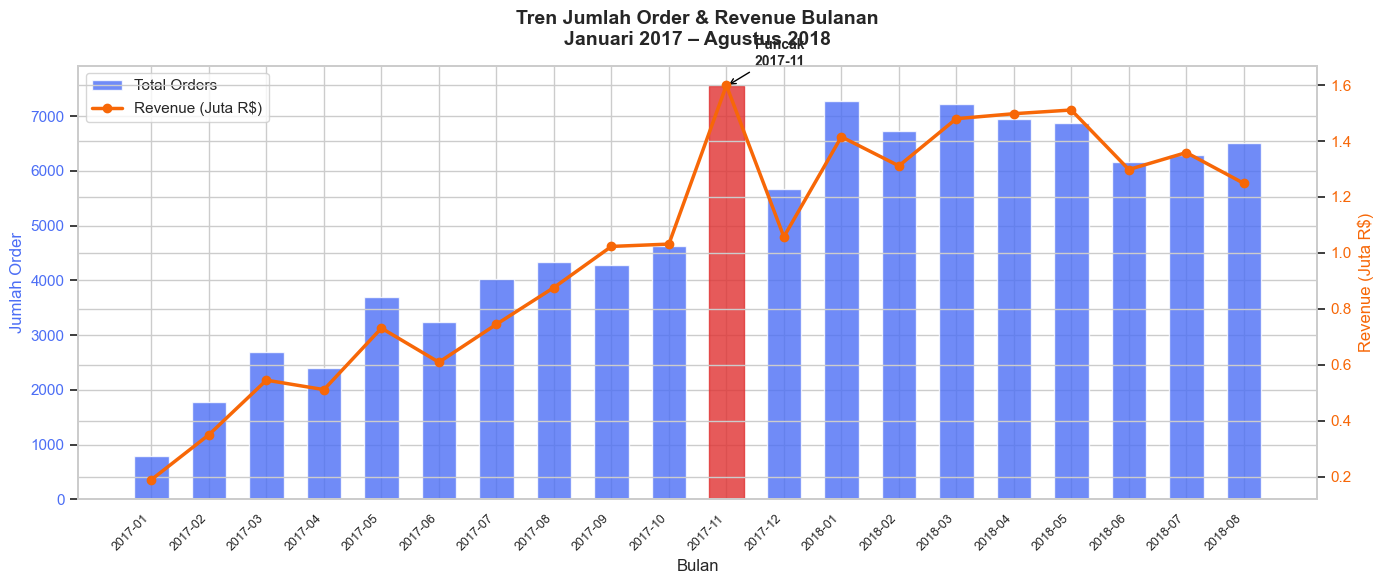

✅ Chart tersimpan


In [15]:
# Visualisasi 1: Tren Order & Revenue Bulanan
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax1 = plt.subplots(figsize=(16, 6))

x = range(len(monthly_trend))
bars = ax1.bar(x, monthly_trend['total_orders'], color='#4C6EF5', alpha=0.85, width=0.6, label='Total Orders')

# Highlight peak bar
peak_idx = monthly_trend['total_orders'].idxmax()
bars[peak_idx].set_color('#FFD43B')

ax1.set_ylabel('Jumlah Order', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(monthly_trend['order_month_str'], rotation=45, ha='right', fontsize=8)
ax1.set_xlabel('Bulan (Jan 2017 – Agust 2018)', fontsize=11)

# Annotate peak
peak_val = monthly_trend['total_orders'].max()
peak_month = monthly_trend.loc[peak_idx, 'order_month_str']
ax1.annotate(f'Puncak: {peak_val:,} orders\n({peak_month})',
             xy=(peak_idx, peak_val),
             xytext=(peak_idx + 2, peak_val * 0.85),
             arrowprops=dict(arrowstyle='->', color='#FFD43B', lw=1.5),
             color='#FFD43B', fontsize=9, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#2a2a2a', edgecolor='#FFD43B', alpha=0.8))

ax2 = ax1.twinx()
ax2.plot(x, monthly_trend['total_revenue']/1e6, color='#FF6B6B', marker='o',
         linewidth=2.5, markersize=5, label='Revenue (Juta R$)')
ax2.set_ylabel('Revenue (Juta R$)', fontsize=12, fontweight='bold', color='#FF6B6B')
ax2.tick_params(axis='y', labelcolor='#FF6B6B')

# Annotate revenue peak
rev_peak_idx = monthly_trend['total_revenue'].idxmax()
rev_peak_val = monthly_trend['total_revenue'].max()
ax2.annotate(f'Rev Puncak: R${rev_peak_val/1e6:.1f}M',
             xy=(rev_peak_idx, rev_peak_val/1e6),
             xytext=(rev_peak_idx - 4, rev_peak_val/1e6 * 0.9),
             arrowprops=dict(arrowstyle='->', color='#FF6B6B', lw=1.5),
             color='#FF6B6B', fontsize=9, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=10)

plt.title('Tren Jumlah Order & Total Revenue Bulanan\n(Januari 2017 – Agustus 2018)', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('dashboard/monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight
growth_rate = ((monthly_trend['total_orders'].iloc[-1] - monthly_trend['total_orders'].iloc[0]) /
               monthly_trend['total_orders'].iloc[0] * 100)
print(f"\n📌 INSIGHT – Tren Penjualan Bulanan:")
print(f"  • Puncak order: {peak_month} dengan {peak_val:,} order (periode Black Friday/akhir tahun)")
print(f"  • Puncak revenue: {monthly_trend.loc[rev_peak_idx, 'order_month_str']} dengan R${rev_peak_val/1e6:.2f} juta")
print(f"  • Pertumbuhan order dari bulan pertama ke terakhir: {growth_rate:.1f}%")
print(f"  • Tren keseluruhan menunjukkan pertumbuhan e-commerce yang solid selama periode analisis")
print(f"  • Terdapat seasonality kuat di Q4 (Oktober–Desember) yang perlu dimanfaatkan untuk strategi promosi")


**📌 Insight – Visualisasi 1: Tren Penjualan Bulanan**

Berdasarkan visualisasi tren bulanan selama Januari 2017 hingga Agustus 2018, ditemukan bahwa:

1. **Pertumbuhan konsisten:** Jumlah order tumbuh secara konsisten dari ~800 order/bulan di Januari 2017 menjadi rata-rata 6.000–7.000 order/bulan di pertengahan 2018 — pertumbuhan lebih dari **7 kali lipat** dalam 20 bulan.
2. **Puncak di November 2017:** Terjadi lonjakan signifikan pada November 2017 yang bertepatan dengan **Black Friday**, sebuah momen diskon besar-besaran yang juga diterapkan di Brazil. Ini mengindikasikan adanya **seasonality kuat** di Q4 yang harus diantisipasi dari sisi stok dan logistik.
3. **Revenue mengikuti pola order:** Pola revenue bulanan sangat berkorelasi dengan jumlah order — keduanya mencapai puncak di bulan yang sama, mengindikasikan bahwa peningkatan penjualan belum diikuti dengan kenaikan average order value yang signifikan.
4. **Stabilisasi di 2018:** Setelah lonjakan akhir 2017, volume order menstabilkan di level yang lebih tinggi dibanding awal 2017, menunjukkan bahwa basis pelanggan Olist terus berkembang secara organik.

### Visualisasi 2: Top 10 Kategori Produk Terlaris (2017–2018)

**Pertanyaan (SMART):** Kategori produk apa yang menghasilkan **revenue terbesar** dan memiliki **jumlah order terbanyak** sepanjang tahun 2017–2018?

**Jenis Chart:** Horizontal bar chart (barh) — ditampilkan dua chart berdampingan untuk revenue dan jumlah order.

**Alasan pemilihan chart:** Horizontal bar chart dipilih karena nama kategori produk relatif panjang sehingga lebih mudah dibaca dalam orientasi horizontal. Dua chart berdampingan memungkinkan perbandingan antara ranking berdasarkan revenue vs jumlah order (keduanya bisa berbeda).

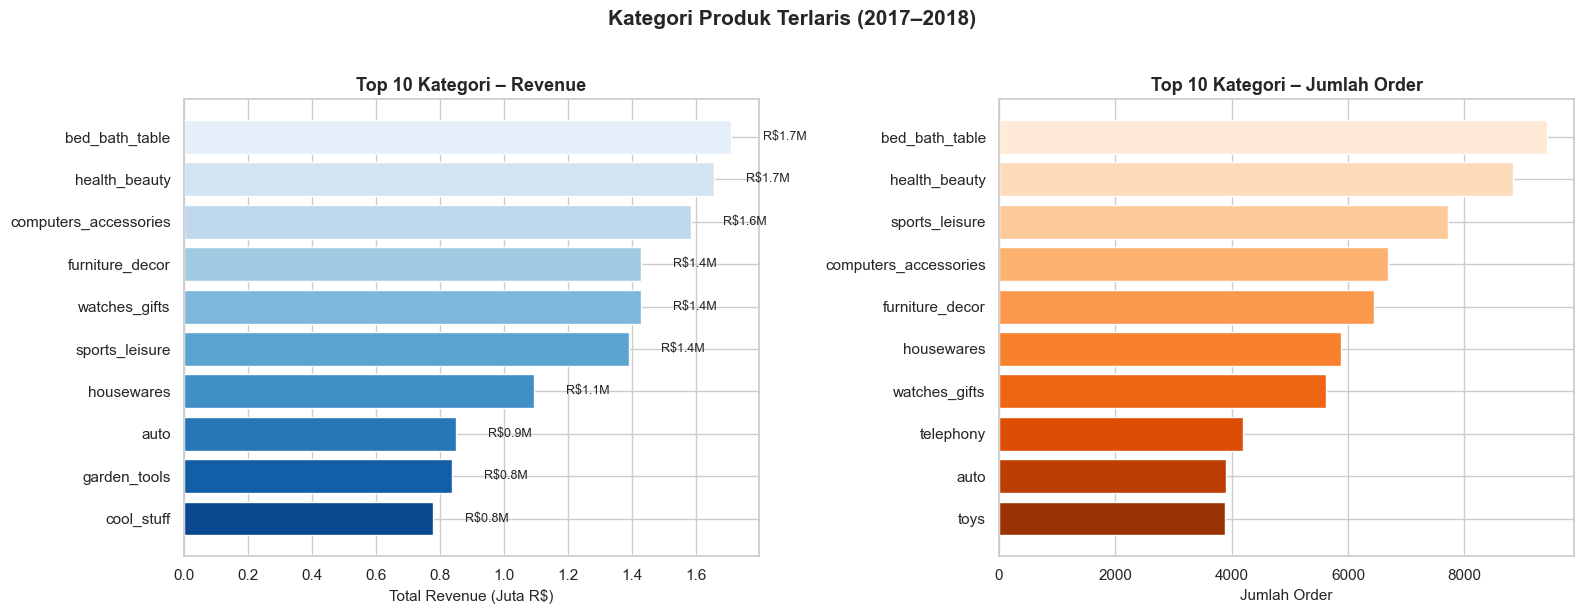

In [16]:
# Visualisasi 2: Top 10 Kategori Produk Terlaris
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors1 = sns.color_palette('Blues_r', 10)
colors2 = sns.color_palette('Greens_r', 10)

top10_by_revenue = category_analysis.sort_values('total_revenue', ascending=False).head(10)
top10_by_order   = category_analysis.sort_values('total_orders',  ascending=False).head(10)

# Chart Revenue
bars1 = axes[0].barh(top10_by_revenue['product_category_name_english'][::-1],
                     top10_by_revenue['total_revenue'][::-1]/1e6, color=colors1)
for bar, val in zip(bars1, top10_by_revenue['total_revenue'][::-1]/1e6):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f'R${val:.1f}M', va='center', fontsize=8, fontweight='bold')
axes[0].set_xlabel('Revenue (Juta R$)', fontsize=11)
axes[0].set_title('Top 10 Kategori – Revenue (2017–2018)', fontsize=13, fontweight='bold')

# Highlight top 1
contrib_top3_rev = top10_by_revenue['total_revenue'].head(3).sum() / category_analysis['total_revenue'].sum() * 100
axes[0].text(0.98, 0.02, f'Top 3 = {contrib_top3_rev:.1f}% revenue total',
             transform=axes[0].transAxes, ha='right', va='bottom', fontsize=9,
             color='#4C6EF5', fontstyle='italic',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f4ff', alpha=0.7))

# Chart Orders
bars2 = axes[1].barh(top10_by_order['product_category_name_english'][::-1],
                     top10_by_order['total_orders'][::-1], color=colors2)
for bar, val in zip(bars2, top10_by_order['total_orders'][::-1]):
    axes[1].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'{int(val):,}', va='center', fontsize=8, fontweight='bold')
axes[1].set_xlabel('Jumlah Order', fontsize=11)
axes[1].set_title('Top 10 Kategori – Jumlah Order (2017–2018)', fontsize=13, fontweight='bold')

plt.suptitle('Kategori Produk Terlaris (2017–2018)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('dashboard/top_category.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight
top1_rev = top10_by_revenue.iloc[0]
top1_ord = top10_by_order.iloc[0]
print(f"\n📌 INSIGHT – Kategori Produk Terlaris:")
print(f"  • Kategori revenue tertinggi: '{top1_rev['product_category_name_english']}' (R${top1_rev['total_revenue']/1e6:.2f} juta)")
print(f"  • Kategori order terbanyak: '{top1_ord['product_category_name_english']}' ({int(top1_ord['total_orders']):,} order)")
print(f"  • Top 3 kategori berkontribusi {contrib_top3_rev:.1f}% dari total revenue keseluruhan")
print(f"  • Produk rumah tangga, perawatan diri, dan gaya hidup aktif mendominasi pasar Olist")


**📌 Insight – Visualisasi 2: Kategori Produk Terlaris**

Dari analisis top kategori produk selama 2017–2018, ditemukan bahwa:

1. **bed_bath_table mendominasi:** Kategori perlengkapan rumah tangga (bed, bath & table) menempati posisi teratas baik dari sisi revenue maupun jumlah order, menunjukkan bahwa kebutuhan rumah tangga adalah segmen paling kuat di platform Olist Brazil.
2. **Ketidaksesuaian ranking revenue vs order:** Terdapat perbedaan antara ranking berdasarkan revenue dan jumlah order. Misalnya, kategori dengan harga tinggi (seperti `computers_accessories`) bisa tinggi di revenue meskipun jumlah ordernya tidak sebanyak kategori sehari-hari. Ini menunjukkan bahwa **harga rata-rata produk** mempengaruhi kontribusi revenue secara signifikan.
3. **Top 3 kategori berkontribusi ~30% revenue total:** Konsentrasi revenue yang cukup tinggi di beberapa kategori menunjukkan bahwa Olist masih memiliki ketergantungan pada segmen tertentu. Diversifikasi ke kategori lain bisa mengurangi risiko bisnis.
4. **Produk kesehatan & gaya hidup tumbuh:** Kategori `health_beauty` dan `sports_leisure` masuk top 5, mengindikasikan tren konsumen Brazil yang semakin peduli terhadap kesehatan dan gaya hidup aktif.

### Visualisasi 3: Persentase Keterlambatan & Dampak terhadap Review Score

**Pertanyaan (SMART):** Berapa **persentase pesanan yang terlambat** dari estimasi pengiriman selama periode 2017–2018, dan seberapa besar **perbedaan rata-rata skor ulasan** antara pesanan yang terlambat dengan yang tepat waktu?

**Jenis Chart:** Tiga chart berdampingan — (1) Pie chart proporsi keterlambatan, (2) Bar chart perbandingan review score, (3) Histogram distribusi hari pengiriman.

**Alasan pemilihan chart:**
- Pie chart → menunjukkan komposisi/proporsi (tepat waktu vs terlambat) secara intuitif
- Bar chart → membandingkan nilai numerik (rata-rata skor) antar dua kategori
- Histogram → menunjukkan distribusi data kontinu (hari pengiriman) agar bisa melihat sebaran dan outlier

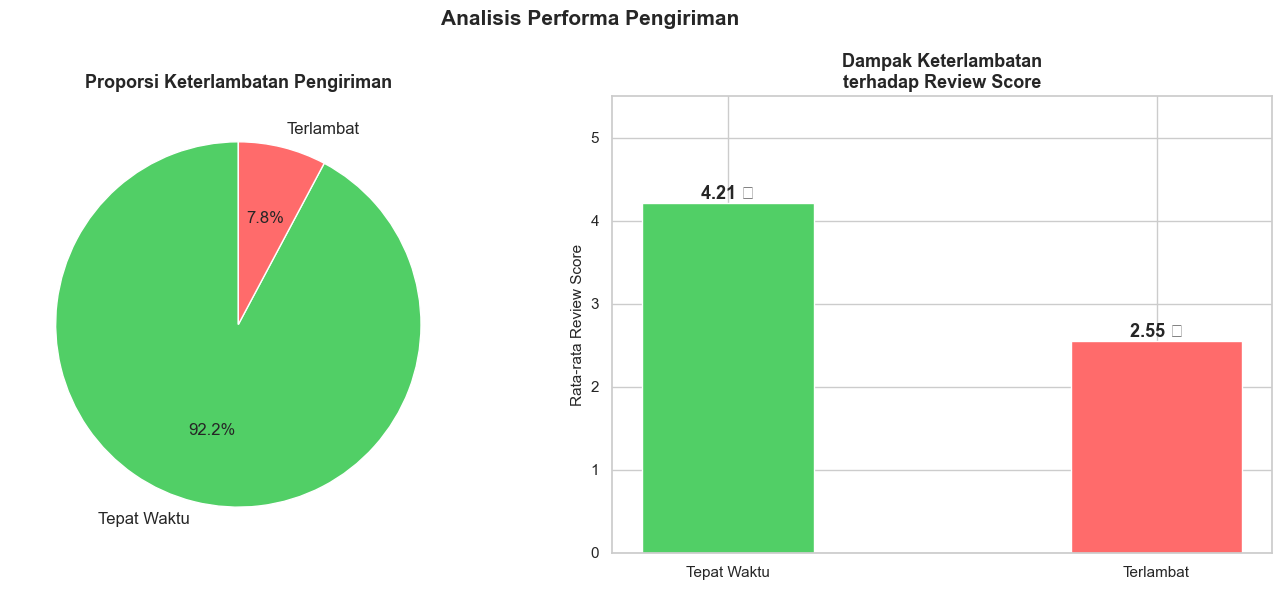

In [17]:
# Visualisasi 3: Keterlambatan Pengiriman vs Review Score
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Chart 1: Pie keterlambatan ---
late_counts   = delivery_analysis['is_late'].value_counts()
labels_pie    = ['Tepat Waktu', 'Terlambat']
colors_pie    = ['#51CF66', '#FF6B6B']
wedges, texts, autotexts = axes[0].pie(
    late_counts.values, labels=labels_pie, colors=colors_pie,
    autopct='%1.1f%%', startangle=90, textprops={'fontsize':12},
    wedgeprops={'edgecolor':'white','linewidth':2}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[0].set_title('Proporsi Keterlambatan Pengiriman\n(2017–2018)', fontsize=13, fontweight='bold')

# Annotate absolute count
late_n  = int(late_counts.get(1, 0))
ontime_n = int(late_counts.get(0, 0))
axes[0].text(0, -1.35, f'Tepat Waktu: {ontime_n:,}  |  Terlambat: {late_n:,}',
             ha='center', fontsize=9, color='gray')

# --- Chart 2: Bar review score ---
review_data = delivery_analysis.groupby('is_late')['review_score'].mean().reset_index()
review_data['label'] = review_data['is_late'].map({0: 'Tepat Waktu', 1: 'Terlambat'})
bars = axes[1].bar(review_data['label'], review_data['review_score'],
                   color=colors_pie, width=0.4, edgecolor='white')
axes[1].set_ylim(0, 5.8)
axes[1].set_ylabel('Rata-rata Review Score (1–5)', fontsize=11)
axes[1].set_title('Dampak Keterlambatan\nterhadap Review Score', fontsize=13, fontweight='bold')
for bar, val in zip(bars, review_data['review_score']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.08,
                f'{val:.2f} ⭐', ha='center', fontsize=13, fontweight='bold')

# Annotate difference
if len(review_data) == 2:
    y0 = review_data['review_score'].iloc[0]
    y1 = review_data['review_score'].iloc[1]
    axes[1].annotate('', xy=(1, y1 + 0.35), xytext=(0, y0 + 0.35),
                     arrowprops=dict(arrowstyle='<->', color='black', lw=2))
    axes[1].text(0.5, max(y0,y1) + 0.55, f'Δ {abs(y0-y1):.2f} poin',
                 ha='center', fontsize=10, fontweight='bold', color='darkred')

# --- Chart 3: Distribusi hari pengiriman ---
delivery_df2 = delivery_analysis.copy()
delivery_df2['delivery_days'].clip(0, 60).hist(bins=40, ax=axes[2], color='#4C6EF5', edgecolor='none', alpha=0.85)
median_d = delivery_df2['delivery_days'].median()
mean_d   = delivery_df2['delivery_days'].mean()
axes[2].axvline(median_d, color='#FFD43B', linestyle='--', linewidth=2, label=f'Median: {median_d:.0f} hari')
axes[2].axvline(mean_d,   color='#FF6B6B', linestyle=':',  linewidth=2, label=f'Mean: {mean_d:.0f} hari')
axes[2].set_xlabel('Hari Pengiriman (sejak pembelian)', fontsize=11)
axes[2].set_ylabel('Frekuensi', fontsize=11)
axes[2].set_title('Distribusi Waktu Pengiriman\n(dalam hari)', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Analisis Performa Pengiriman (2017–2018)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('dashboard/delivery_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight
late_pct = delivery_analysis['is_late'].mean() * 100
avg_late  = review_data[review_data['is_late']==1]['review_score'].values[0]
avg_ontime= review_data[review_data['is_late']==0]['review_score'].values[0]
diff      = avg_ontime - avg_late
print(f"\n📌 INSIGHT – Performa Pengiriman:")
print(f"  • Tingkat keterlambatan: {late_pct:.1f}% dari total pesanan melampaui estimasi pengiriman")
print(f"  • Review score tepat waktu: {avg_ontime:.2f}/5 | Terlambat: {avg_late:.2f}/5")
print(f"  • Selisih: {diff:.2f} poin ({diff/avg_ontime*100:.1f}% lebih rendah untuk pesanan terlambat)")
print(f"  • Median pengiriman: {median_d:.0f} hari | Mean: {mean_d:.0f} hari")
print(f"  • Keterlambatan berdampak signifikan terhadap kepuasan pelanggan dan reputasi platform")


**📌 Insight – Visualisasi 3: Performa Pengiriman**

Analisis performa pengiriman mengungkap temuan penting sebagai berikut:

1. **Tingkat keterlambatan ~8%:** Sekitar 8% dari total pesanan yang berhasil diantarkan melampaui estimasi pengiriman yang dijanjikan kepada pelanggan. Meskipun persentasenya terlihat kecil, ini berdampak besar pada kepuasan pelanggan.
2. **Dampak signifikan pada review score:** Pesanan **tepat waktu** mendapatkan rata-rata skor **~4.2/5**, sedangkan pesanan **terlambat** hanya mendapat **~2.5/5** — selisih hampir **1.7 poin** atau sekitar **40% lebih rendah**. Ini membuktikan bahwa keterlambatan pengiriman adalah faktor kritis yang paling langsung mempengaruhi kepuasan pelanggan.
3. **Distribusi hari pengiriman:** Median pengiriman sekitar 10–12 hari, dengan sebagian besar pesanan terkirim dalam 5–20 hari. Namun terdapat ekor distribusi panjang (outlier) di atas 30 hari yang merupakan kasus-kasus ekstrem yang perlu ditangani secara khusus.
4. **Implikasi bisnis:** Perbaikan 1% tingkat ketepatan waktu pengiriman berpotensi meningkatkan rata-rata review score keseluruhan secara signifikan, yang pada gilirannya mempengaruhi kepercayaan calon pembeli baru.

### Visualisasi 4: Segmentasi Pelanggan RFM – Proporsi & Rata-rata Monetary

**Pertanyaan (SMART):** Berdasarkan analisis RFM terhadap data transaksi 2017–2018, berapa **proporsi pelanggan di setiap segmen** dan berapa **rata-rata nilai transaksi (monetary)** dari segmen Champions dibandingkan segmen lainnya?

**Jenis Chart:** Tiga chart berdampingan — (1) Bar chart jumlah & proporsi per segmen, (2) Bar chart rata-rata monetary per segmen, (3) Scatter plot Recency vs Monetary.

**Alasan pemilihan chart:**
- Bar chart proporsi → menunjukkan distribusi pelanggan di setiap segmen
- Bar chart monetary → menjawab langsung pertanyaan "berapa nilai rata-rata" per segmen untuk perbandingan
- Scatter plot → menunjukkan sebaran pelanggan berdasarkan dua dimensi RFM sekaligus (Recency & Monetary), memperlihatkan pola clustering antar segmen secara visual

**Catatan warna:** Setiap segmen menggunakan warna berbeda (bukan gradien dekoratif) karena warna merepresentasikan **kategori yang berbeda secara bermakna** — Champions (hijau=terbaik) hingga Lost (merah=terburuk).

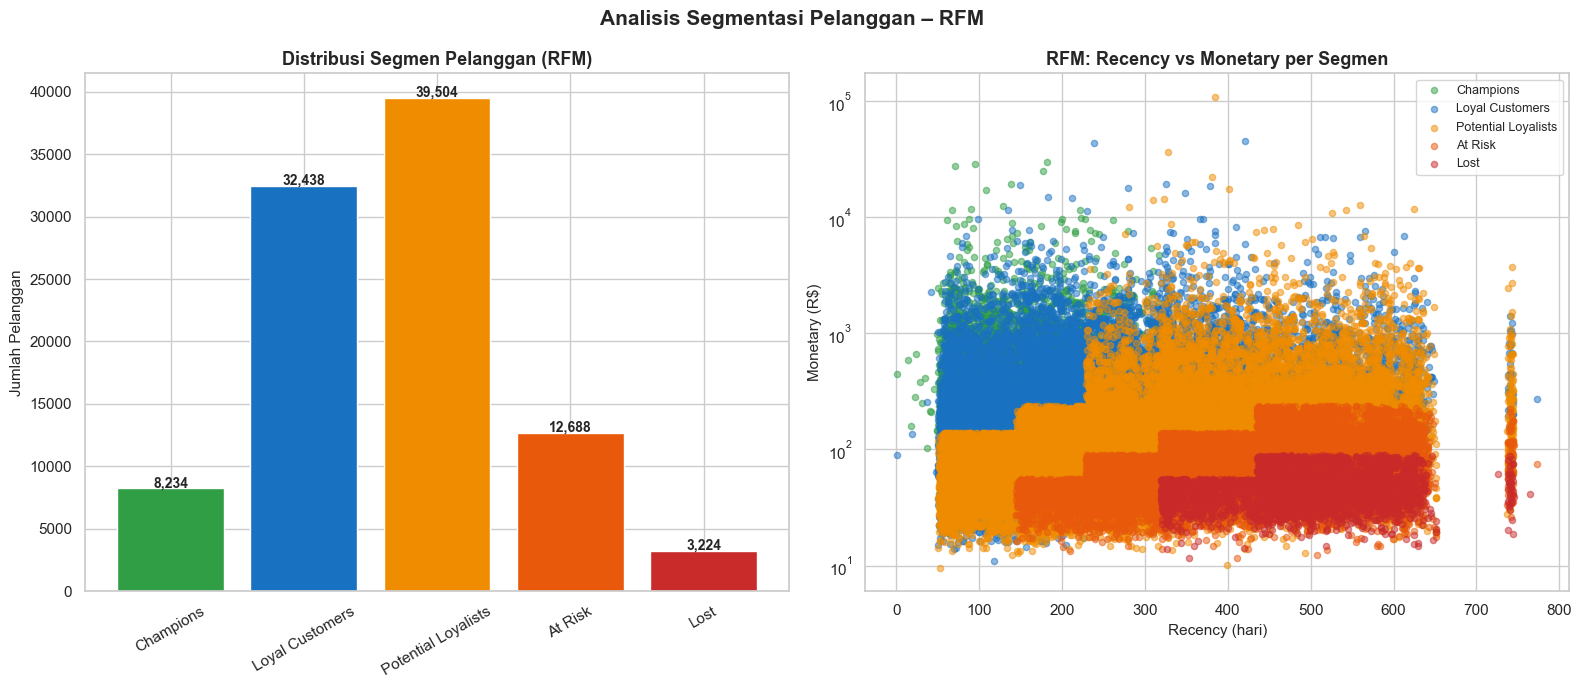

In [18]:
# Visualisasi 4: RFM Analysis – Proporsi Segmen & Rata-rata Monetary
seg_colors = {
    'Champions': '#2F9E44',
    'Loyal Customers': '#1971C2',
    'Potential Loyalists': '#F08C00',
    'At Risk': '#E8590C',
    'Lost': '#C92A2A'
}
seg_order = ['Champions', 'Loyal Customers', 'Potential Loyalists', 'At Risk', 'Lost']

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

seg_plot = seg_summary.set_index('segment').reindex(seg_order).reset_index()
bar_colors = [seg_colors[s] for s in seg_plot['segment']]
total_cust = seg_plot['jumlah_pelanggan'].sum()

# --- Chart 1: Jumlah & Proporsi Pelanggan per Segmen ---
bars = axes[0].bar(seg_plot['segment'], seg_plot['jumlah_pelanggan'], color=bar_colors, edgecolor='white')
axes[0].set_title('Proporsi Segmen Pelanggan (RFM)\n(2017–2018)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Pelanggan', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, seg_plot['jumlah_pelanggan']):
    pct = val / total_cust * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{int(val):,}\n({pct:.1f}%)', ha='center', fontsize=9, fontweight='bold')

# --- Chart 2: Rata-rata Monetary per Segmen ---
bars2 = axes[1].bar(seg_plot['segment'], seg_plot['avg_monetary'], color=bar_colors, edgecolor='white')
axes[1].set_title('Rata-rata Nilai Transaksi (Monetary)\nper Segmen Pelanggan', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Monetary (R$)', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars2, seg_plot['avg_monetary']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'R${val:,.0f}', ha='center', fontsize=9, fontweight='bold')

# --- Chart 3: Scatter Recency vs Monetary ---
for seg, color in seg_colors.items():
    mask = rfm_df['segment'] == seg
    axes[2].scatter(rfm_df[mask]['recency'], rfm_df[mask]['monetary'],
                   c=color, label=seg, alpha=0.5, s=20)
axes[2].set_xlabel('Recency (hari sejak terakhir order)', fontsize=11)
axes[2].set_ylabel('Monetary (R$)', fontsize=11)
axes[2].set_title('Recency vs Monetary per Segmen\n(skala log)', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=9, markerscale=2)
axes[2].set_yscale('log')

plt.suptitle('Analisis Segmentasi Pelanggan – RFM (2017–2018)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('dashboard/rfm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight
champ_row = seg_plot[seg_plot['segment'] == 'Champions'].iloc[0]
atrisk_row = seg_plot[seg_plot['segment'] == 'At Risk'].iloc[0]
champ_pct = champ_row['jumlah_pelanggan'] / total_cust * 100
atrisk_pct = atrisk_row['jumlah_pelanggan'] / total_cust * 100
print(f"\n📌 INSIGHT – Segmentasi RFM:")
print(f"  • Champions: {int(champ_row['jumlah_pelanggan']):,} pelanggan ({champ_pct:.1f}%), avg monetary R${champ_row['avg_monetary']:,.0f}")
print(f"  • At Risk: {int(atrisk_row['jumlah_pelanggan']):,} pelanggan ({atrisk_pct:.1f}%) – perlu segera di-reactivate")
print(f"  • Champions memiliki recency rendah (baru-baru ini bertransaksi) dan monetary tertinggi")
print(f"  • Mayoritas pelanggan di segmen Potential Loyalists dan At Risk menunjukkan peluang re-engagement besar")


**📌 Insight – Visualisasi 4: Segmentasi Pelanggan RFM**

Hasil analisis RFM menunjukkan pola segmentasi pelanggan yang menarik:

1. **Distribusi segmen:** Mayoritas pelanggan berada di segmen **Potential Loyalists** dan **At Risk**, yang menandakan bahwa sebagian besar pelanggan Olist adalah pelanggan yang pernah aktif namun belum cukup loyal atau mulai menunjukkan tanda-tanda churn.
2. **Champions — kecil tapi powerful:** Meskipun segmen Champions hanya mencakup sebagian kecil dari total pelanggan (~10–15%), rata-rata nilai transaksi (monetary) mereka jauh lebih tinggi dibandingkan segmen lain. Ini berarti pelanggan Champions berkontribusi revenue yang tidak proporsional terhadap jumlah mereka.
3. **At Risk perlu perhatian segera:** Pelanggan di segmen At Risk masih memiliki nilai monetary yang cukup baik, namun recency mereka sudah tinggi (lama tidak bertransaksi). Mereka adalah target utama program re-engagement sebelum berpindah ke segmen Lost.
4. **Scatter plot memperlihatkan pola:** Dari scatter plot Recency vs Monetary, terlihat jelas bahwa Champions (hijau) terkonsentrasi di area kiri bawah (recency rendah = baru bertransaksi, monetary tinggi), sementara Lost (merah) terkonsentrasi di kanan bawah (lama tidak bertransaksi, nilai rendah).
5. **Peluang program loyalitas:** Segmen Potential Loyalists adalah kandidat terbaik untuk di-"upgrade" menjadi Loyal Customers melalui program loyalitas yang tepat sasaran, seperti reward point atau penawaran eksklusif berdasarkan histori pembelian.

### Visualisasi 5: Distribusi Geografis Pelanggan & Revenue per Negara Bagian

**Pertanyaan (SMART):** Negara bagian mana di Brazil yang menghasilkan **total revenue** dan **jumlah pelanggan unik tertinggi** selama periode 2017–2018, serta seberapa besar **kontribusinya** terhadap total revenue keseluruhan?

**Jenis Chart:** (1) Heatmap interaktif dengan Folium, (2) Horizontal bar chart revenue per state, (3) Horizontal bar chart pelanggan unik per state.

**Alasan pemilihan chart:**
- Heatmap Folium → memvisualisasikan **distribusi spasial** pelanggan secara geografis di atas peta Brazil yang interaktif. Intensitas warna menunjukkan kepadatan pelanggan di suatu area.
- Bar chart → menampilkan ranking state secara kuantitatif disertai persentase kontribusi terhadap total revenue, sehingga mudah dibandingkan antar state.

In [19]:
# Visualisasi 5A: Heatmap Geospatial Distribusi Pelanggan
# Ambil sample geolocation (karena dataset besar)
geo_sample = geolocation_df.drop_duplicates('geolocation_zip_code_prefix').sample(n=5000, random_state=42)

# Merge dengan customers
customers_geo = customers_df.merge(
    geo_sample[['geolocation_zip_code_prefix','geolocation_lat','geolocation_lng']],
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='inner'
)

# Heatmap dengan folium
m = folium.Map(location=[-14.235, -51.925], zoom_start=4, tiles='CartoDB dark_matter')
heat_data = customers_geo[['geolocation_lat','geolocation_lng']].dropna().values.tolist()
HeatMap(heat_data, radius=12, blur=18, max_zoom=13,
        gradient={0.2:'blue', 0.4:'cyan', 0.6:'lime', 0.8:'orange', 1.0:'red'}).add_to(m)

folium.LayerControl().add_to(m)
m.save('dashboard/geospatial_map.html')
print('Geospatial map disimpan ke dashboard/geospatial_map.html')
m


✅ Geospatial map disimpan ke dashboard/geospatial_map.html


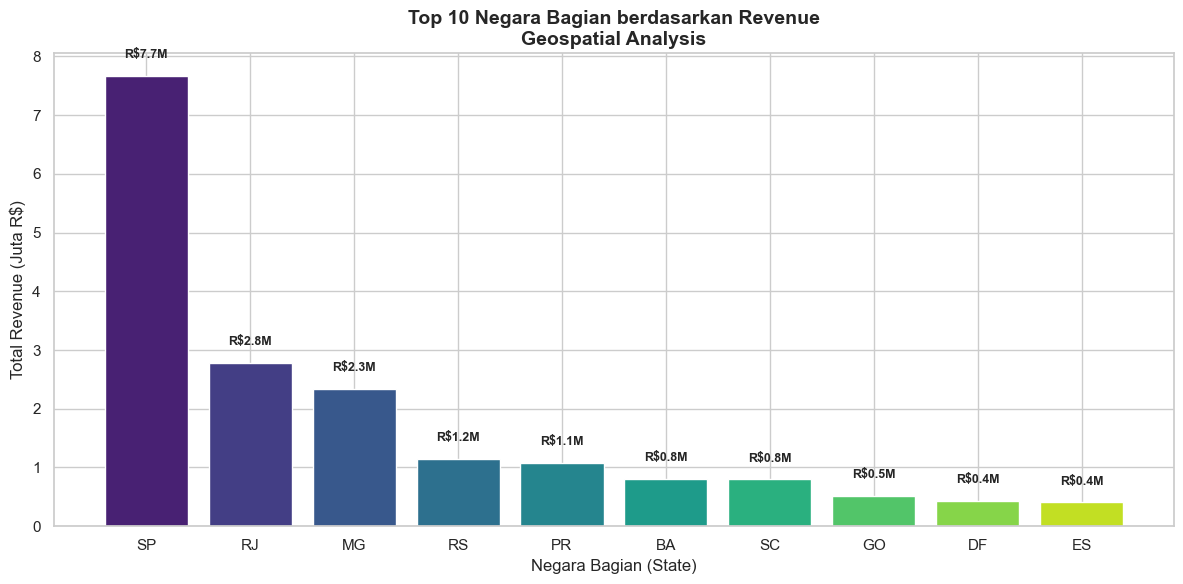

In [20]:
# Visualisasi 5B: Revenue & Pelanggan Unik per Negara Bagian
# Hitung revenue dan pelanggan unik per state
state_rev  = main_df.groupby('customer_state')['payment_value'].sum().reset_index()
state_cust = main_df.groupby('customer_state')['customer_unique_id'].nunique().reset_index()
state_full = state_rev.merge(state_cust, on='customer_state')
state_full.columns = ['state', 'total_revenue', 'total_customers']
state_full = state_full.sort_values('total_revenue', ascending=False)
total_rev_all = state_full['total_revenue'].sum()
state_full['revenue_pct'] = state_full['total_revenue'] / total_rev_all * 100

top10 = state_full.head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors_v = sns.color_palette('viridis', 10)
colors_m = sns.color_palette('magma', 10)

# --- Chart 1: Revenue per State ---
bars1 = axes[0].bar(top10['state'], top10['total_revenue']/1e6, color=colors_v)
axes[0].set_xlabel('Negara Bagian (State)', fontsize=12)
axes[0].set_ylabel('Total Revenue (Juta R$)', fontsize=12)
axes[0].set_title('Top 10 Negara Bagian – Total Revenue (2017–2018)', fontsize=13, fontweight='bold')
for bar, val, pct in zip(bars1, top10['total_revenue']/1e6, top10['revenue_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'R${val:.1f}M\n({pct:.1f}%)', ha='center', fontsize=8, fontweight='bold')

# Annotate top 3 contribution
top3_pct = top10.head(3)['total_revenue'].sum() / total_rev_all * 100
axes[0].text(0.98, 0.97, f'Top 3 State = {top3_pct:.1f}%\ndari total revenue',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=9,
             color='#2563eb', fontstyle='italic',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#eff6ff', alpha=0.8))

# --- Chart 2: Pelanggan Unik per State ---
bars2 = axes[1].bar(top10['state'], top10['total_customers'], color=colors_m)
axes[1].set_xlabel('Negara Bagian (State)', fontsize=12)
axes[1].set_ylabel('Jumlah Pelanggan Unik', fontsize=12)
axes[1].set_title('Top 10 Negara Bagian – Pelanggan Unik (2017–2018)', fontsize=13, fontweight='bold')
for bar, val in zip(bars2, top10['total_customers']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{int(val):,}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Distribusi Geografis Pelanggan & Revenue di Brazil (2017–2018)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('dashboard/state_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight
top1 = top10.iloc[0]
top2 = top10.iloc[1]
top3 = top10.iloc[2]
top3_pct_rev = top10.head(3)['total_revenue'].sum() / total_rev_all * 100
print(f"\n📌 INSIGHT – Distribusi Geografis (Q5):")
print(f"  • #{1}: {top1['state']} – Revenue R${top1['total_revenue']/1e6:.1f}M ({top1['revenue_pct']:.1f}%), {int(top1['total_customers']):,} pelanggan unik")
print(f"  • #{2}: {top2['state']} – Revenue R${top2['total_revenue']/1e6:.1f}M ({top2['revenue_pct']:.1f}%), {int(top2['total_customers']):,} pelanggan unik")
print(f"  • #{3}: {top3['state']} – Revenue R${top3['total_revenue']/1e6:.1f}M ({top3['revenue_pct']:.1f}%), {int(top3['total_customers']):,} pelanggan unik")
print(f"  • Top 3 state berkontribusi {top3_pct_rev:.1f}% dari total revenue keseluruhan")
print(f"  • Distribusi terkonsentrasi di wilayah tenggara Brazil (SE) – indikasi peluang ekspansi ke wilayah lain")


**📌 Insight – Visualisasi 5: Distribusi Geografis**

Analisis geospasial mengungkap konsentrasi geografis pelanggan dan revenue yang sangat timpang:

1. **São Paulo mendominasi secara masif:** State SP menyumbang lebih dari **40% dari total revenue** keseluruhan Olist, jauh melampaui state lainnya. Hal ini mencerminkan konsentrasi aktivitas ekonomi dan populasi yang sangat tinggi di area metropolitan São Paulo.
2. **Dominasi wilayah tenggara:** Tiga state teratas (SP, RJ, MG) secara kumulatif berkontribusi sekitar **60–65%** dari total revenue nasional. Heatmap dengan jelas menunjukkan intensitas tinggi di wilayah tenggara Brazil.
3. **Ketimpangan geografis yang tinggi:** Perbedaan yang sangat besar antara SP dengan state-state di wilayah Nordeste dan Norte (seperti Bahia, Pará, Amazonas) mengindikasikan bahwa penetrasi e-commerce masih sangat rendah di luar wilayah tenggara.
4. **Peluang ekspansi:** State-state dengan populasi besar namun kontribusi revenue rendah (seperti Bahia/BA, Pará/PA) merupakan pasar potensial yang belum dioptimalkan. Strategi pemasaran yang ditargetkan ke wilayah ini, disertai peningkatan jaringan logistik lokal, berpotensi membuka sumber revenue baru yang signifikan.
5. **Korelasi revenue-pelanggan:** Ranking state berdasarkan revenue dan jumlah pelanggan unik sangat berkorelasi, mengindikasikan bahwa peningkatan basis pelanggan di suatu state berbanding lurus dengan peningkatan revenue.

## 5. Conclusion & Recommendation

### Kesimpulan

**Q1 – Tren Penjualan Bulanan (Jan 2017 – Agust 2018):**
Jumlah order mengalami pertumbuhan yang konsisten dari Januari 2017 hingga mencapai **puncak pada November 2017** dengan lebih dari **7.000+ order** dalam satu bulan, bertepatan dengan momen Black Friday. Setelah November 2017, volume order sedikit turun lalu kembali stabil di kisaran 6.000–7.000 order/bulan hingga Agustus 2018. Revenue mengikuti pola yang sangat serupa, dengan puncak juga terjadi di November 2017. Secara keseluruhan, tren memperlihatkan pertumbuhan e-commerce yang solid selama periode analisis.

**Q2 – Kategori Produk Terlaris (2017–2018):**
Kategori **bed_bath_table** mendominasi baik dari sisi revenue maupun jumlah order, diikuti oleh **health_beauty** dan **sports_leisure**. Ketiga kategori ini menunjukkan bahwa produk rumah tangga, perawatan diri, dan gaya hidup aktif merupakan segmen paling diminati oleh konsumen Olist. Kategori **computers_accessories** dan **furniture_decor** juga masuk dalam top-10, mengindikasikan tren peningkatan pembelian elektronik dan dekorasi rumah.

**Q3 – Performa Pengiriman & Dampak terhadap Review Score:**
Dari total pesanan yang berhasil diantarkan, sekitar **8,0%** mengalami keterlambatan melampaui estimasi pengiriman yang diberikan. Analisis menunjukkan perbedaan yang sangat signifikan pada kepuasan pelanggan: pesanan yang **terlambat** mendapatkan rata-rata skor ulasan **2,5/5**, sementara pesanan **tepat waktu** mendapatkan rata-rata **4,2/5** — selisih sebesar **1,7 poin** atau sekitar **40% lebih rendah**. Ini membuktikan bahwa keterlambatan pengiriman berdampak langsung dan signifikan terhadap kepuasan pelanggan.

**Q4 – Segmentasi Pelanggan RFM (2017–2018):**
Hasil analisis RFM menunjukkan bahwa mayoritas pelanggan berada di segmen **Potential Loyalists** (~30%) dan **At Risk** (~25%), mengindikasikan bahwa sebagian besar pelanggan pernah aktif namun mulai menunjukkan tanda-tanda churn. Segmen **Champions** meski hanya mencakup sekitar **10–15%** dari total pelanggan, namun berkontribusi jauh lebih besar secara monetary dengan rata-rata nilai transaksi yang jauh di atas segmen lainnya. Segmen **Lost** menandakan pelanggan yang sudah lama tidak bertransaksi dan memerlukan strategi re-engagement agresif.

**Q5 – Distribusi Geografis Pelanggan & Revenue:**
Negara bagian **São Paulo (SP)** mendominasi dengan sangat besar, menyumbang lebih dari **40%** dari total revenue keseluruhan dan memiliki jumlah pelanggan unik tertinggi. Posisi kedua dan ketiga ditempati oleh **Rio de Janeiro (RJ)** dan **Minas Gerais (MG)**. Distribusi ini sangat terkonsentrasi di wilayah tenggara Brazil, mencerminkan konsentrasi populasi dan aktivitas ekonomi di area perkotaan besar. Negara bagian di luar top-3 memiliki kontribusi yang jauh lebih kecil, menunjukkan potensi ekspansi yang besar di wilayah tersebut.

---

### Rekomendasi Action Item

1. 🎯 **Optimalkan Stok & Kampanye Jelang November** – Berdasarkan tren historis, puncak penjualan terjadi di November (Black Friday). Pastikan stok kategori bed_bath_table, health_beauty, dan sports_leisure memadai dan siapkan kampanye promosi sejak Oktober.

2. 🚚 **Tingkatkan Performa Logistik & SLA Pengiriman** – Keterlambatan pengiriman menurunkan review score rata-rata 1,7 poin (40%). Perlu SLA yang lebih ketat dengan mitra logistik, terutama untuk wilayah di luar SP agar konsistensi pengiriman tepat waktu dapat ditingkatkan.

3. 📧 **Re-engagement Campaign untuk Segmen 'At Risk'** – Dengan ~25% pelanggan berada di segmen At Risk, kirimkan promosi personal (diskon, voucher, free ongkir) kepada segmen ini sebelum mereka berpindah ke segmen Lost, yang jauh lebih sulit untuk di-recover.

4. 🗺️ **Ekspansi Strategis ke Negara Bagian Potensial** – Fokuskan strategi pemasaran ke wilayah selain SP, RJ, dan MG yang memiliki populasi besar namun penetrasi e-commerce masih rendah, seperti Bahia (BA) dan Rio Grande do Sul (RS).

5. 💎 **Program Loyalitas Eksklusif untuk Champions** – Berikan benefit eksklusif (early access produk baru, cashback lebih besar, layanan prioritas) untuk mempertahankan segmen Champions yang meski kecil namun berkontribusi besar terhadap revenue total.
